In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from scipy.cluster import hierarchy

%load_ext autoreload
%autoreload 2
import imp
from utils import load_animal_region_kernels, load_animal_kernels, list_regions, list_animals, filter_kernels_outliers, detect_outlier_subjects
from matplotlib.colors import Normalize
from metric import dsd


/tmp/ipykernel_64460/2773931419.py:11: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


In [2]:
genotypes = ['N', 'C', 'F', 'S']
genotype = 'C'
regions = list_regions(genotype)
animals = list_animals(genotype)

animal = 'CSP013'
region = 'MOs'

animal_kernel_region = load_animal_region_kernels(genotype, animal, region) # Give kernals across all units of this region
animal_kernel = load_animal_kernels(genotype, regions, animal) # Give kernals across all units contrasts and time (n_units, n_contrasts, n_time_bins)


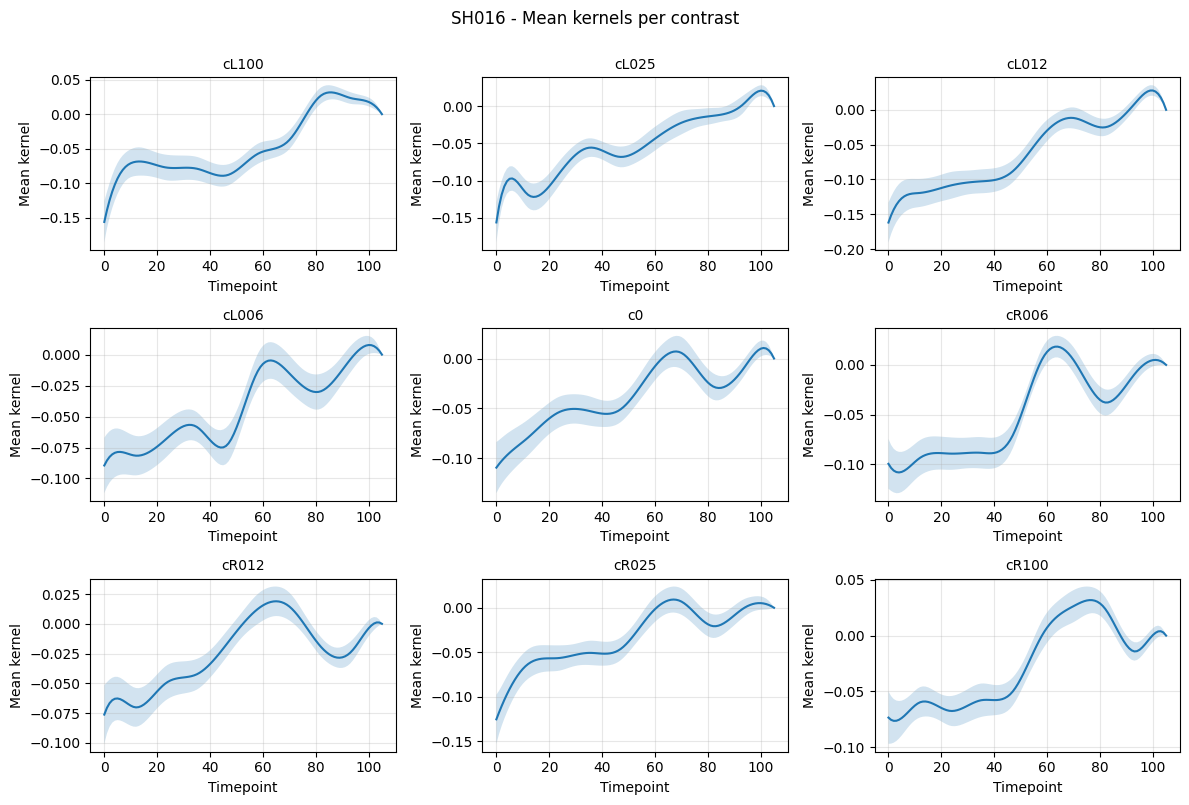

In [24]:
contrast_names = ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

animal_kernel_filter = filter_kernels_outliers(animal_kernel)
for c_idx, contrast in enumerate(contrast_names):
    kernel_contrast = animal_kernel_filter[:, c_idx, :]
    mean_kernel = kernel_contrast.mean(axis=0)
    
    axes[c_idx].plot(mean_kernel, linewidth=1.5)
    sem = kernel_contrast.std(axis=0) / np.sqrt(kernel_contrast.shape[0])
    axes[c_idx].fill_between(np.arange(len(mean_kernel)), mean_kernel - sem, mean_kernel + sem, alpha=0.2)
    axes[c_idx].set_title(contrast, fontsize=10)
    axes[c_idx].grid(True, alpha=0.3)
    axes[c_idx].set_xlabel('Timepoint')
    axes[c_idx].set_ylabel('Mean kernel')

plt.suptitle(f'{animal} - Mean kernels per contrast', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

### Across all subjects/genptypes

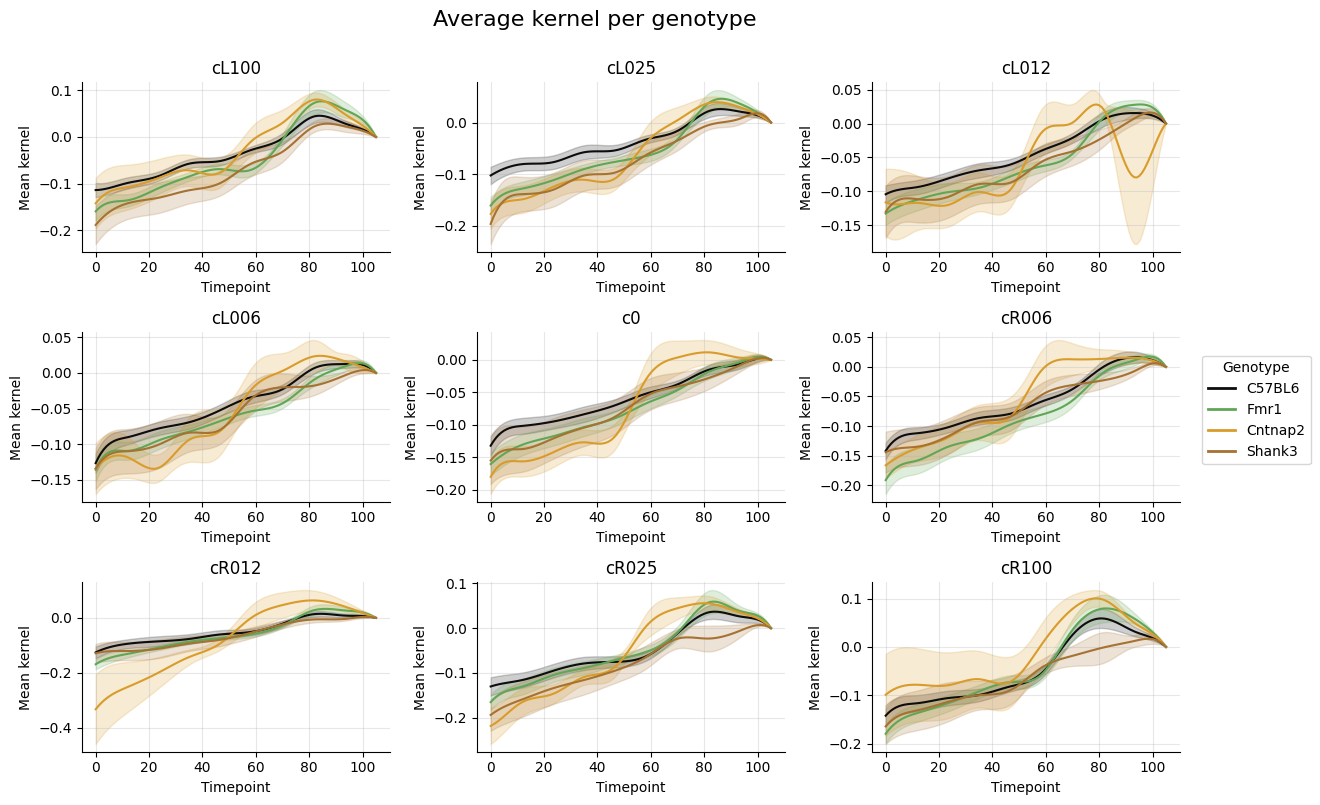

In [3]:
# Plot average kernel per genotype across all regions 
from collections import defaultdict
from matplotlib.lines import Line2D


genotypes = ['N', 'F', 'C', 'S']
contrast_names =    ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']
#colors = {'C':'blue', 'F':'red', 'N':'green', 'S':'orange'}
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

# For each genotype, for each region, get kernel and average across all neurons
genotype_kernels_neurons = defaultdict(list)
all_animals = []
for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    all_animals.extend(animals_g)
    for animal in animals_g:
        animal_kernel = load_animal_kernels(g, regions, animal) # (n_units, n_contrasts, n_time_bins)
        # Filter for outliers
        animal_kernel_filter = filter_kernels_outliers(animal_kernel, 97.5, 2.5)

        # If after filtering there are no more kernels left, skip this animal
        if len(animal_kernel_filter) > 0:
            genotype_kernels_neurons[g].append(animal_kernel_filter) # (subjects, n_units, contrasts, timepoints)

# Plot mean kernel across animals for each genotype and contrast - ignoring per-region and just agregating genotype
for c_idx, contrast in enumerate(contrast_names):
    ax = axes[c_idx]
    for g in genotypes:
        arrs = genotype_kernels_neurons[g]
        if len(arrs) == 0:
            continue
        vals = np.stack([a[:, c_idx, :].mean(axis=0) for a in arrs if len(a) > 0], axis=0) # (subjects, timepoints) for contrast c_idx
        mean = vals.mean(axis=0) # (n_units, timepoints)
        sem = vals.std(axis=0) / np.sqrt(vals.shape[0])
        ax.plot(mean, label=g, color=colors[g], linewidth=1.5)
        ax.fill_between(np.arange(len(mean)), mean - sem, mean + sem, color=colors[g], alpha=0.2)
    ax.set_title(contrast, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Mean kernel')

handles = [Line2D([0], [0], color=colors[g], lw=2) for g in genotypes if len(genotype_kernels_neurons[g]) > 0]
labels = [map_labels[g] for g in genotypes if len(genotype_kernels_neurons[g]) > 0]
plt.suptitle('Average kernel per genotype', fontsize=16, y=1.00)
plt.tight_layout()
sns.despine()
fig.legend(handles=handles, labels=labels, title='Genotype', bbox_to_anchor=(1, 0.5), loc='center left')
plt.show()

In [4]:
genotype_kernels_neurons['C'][3].shape

(197, 9, 106)

## Shape metrics

### Functions

In [44]:
def plot_pca(dist_matrix, labels):

    # PCA on distance matrix
    pca_2d = PCA(n_components=2)
    pca_coords = pca_2d.fit_transform(dist_matrix)

    colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

    fig, ax = plt.subplots(figsize=(6, 5))

    # PCA on MDS plot
    for g in np.unique(labels):
        mask = np.array(labels) == g
        ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                        c=colors[g], label=map_labels[g], s=60, edgecolors='white', linewidths=0.5)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('PCA on MDS embedding')
    ax.legend()

    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_mds_pca(dist_matrix, labels, n_components=50, ax=None):

    # DIstance matrices are not euclidean so PCA directly is not ideal
    # MDS on the distance matrix
    mds = MDS(n_components=n_components, 
              dissimilarity='precomputed', 
              random_state=66,
              normalized_stress=False,
              n_init=10,)
    
    mds_coords = mds.fit_transform(dist_matrix)

    # PCA on MDS coordinates
    pca_2d = PCA(n_components=2, random_state=42)
    pca_coords = pca_2d.fit_transform(mds_coords)

    colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # PCA on MDS plot
    for g in np.unique(labels):
        mask = np.array(labels) == g
        ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                        c=colors[g], label=map_labels[g], s=60, edgecolors='white', linewidths=0.5)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('PCA on MDS embedding', fontsize=13, fontweight='bold')
    ax.legend()

    return ax

def plot_mds_tsne(dist_matrix, labels, n_components=50, perplexity=20, ax=None):

    # DIstance matrices are not euclidean so PCA directly is not ideal
    # MDS on the distance matrix
    mds = MDS(n_components=n_components, 
              dissimilarity='precomputed', 
              random_state=66,
              normalized_stress=False,
              n_init=10,)
    
    mds_coords = mds.fit_transform(dist_matrix)

    # TSNE on MDS coordinates
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    tsne_coords = tsne.fit_transform(mds_coords)

    colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # TSNE on MDS plot
    for g in np.unique(labels):
        mask = np.array(labels) == g
        ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                        c=colors[g], label=map_labels[g], s=60, edgecolors='white', linewidths=0.5)
    ax.set_title('TSNE on MDS embedding', fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_xlabel('tSNE1')
    ax.set_ylabel('tSNE2')

    return ax

In [45]:
# 106 time points is a lot for clustering, maybe I can split them into 10 bins and average within each bin to reduce dimensionality and noise?
def split_time_bins(arr, n_bins=10):
    """Split the last dimension of arr into n_bins and average within each bin."""
    if arr.shape[-1] % n_bins != 0:
        arr = arr[:, :, :-(arr.shape[-1] % n_bins)] # Trim the last dimension to be divisible by n_bins
    return arr.reshape(*arr.shape[:-1], n_bins, -1).mean(-1)

In [46]:
### Statistical tests

# How to test whether the distance between genotypes is significant? 
# I can do a permutation test where I shuffle the genotype labels and recompute the distance matrix

def permutation_test(dist_matrix, labels, n_perms=1000):

    # Null hypothesis: the distance between genotypes is not different from the distance within genotypes

    S = len(labels)

    # Masks for within/between genotype distances
    within_mask = np.zeros((S, S), dtype=bool)
    between_mask = np.zeros((S, S), dtype=bool)
    for i in range(S):
        for j in range(S):
            if i != j:
                if labels[i] == labels[j]:
                    within_mask[i, j] = True
                else:
                    between_mask[i, j] = True

    obs_stat = dist_matrix[between_mask].mean() - dist_matrix[within_mask].mean()

    # Permutation null distribution
    perm_stats = np.zeros(n_perms)
    for k in range(n_perms):
        perm_labels = np.random.permutation(labels)
        # Permute the masks according to the permuted labels
        wm = np.array([[perm_labels[i] == perm_labels[j] and i != j for j in range(S)] for i in range(S)])
        bm = np.array([[perm_labels[i] != perm_labels[j] for j in range(S)] for i in range(S)])
        perm_stats[k] = dist_matrix[bm].mean() - dist_matrix[wm].mean()

    p_value = np.mean(perm_stats >= obs_stat)
    print(f"Observed statistic (between - within): {obs_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    return p_value, perm_stats, obs_stat

In [47]:

def plot_dendogram(dist_neural, labs, save=False, lab_to_color=None):
    
    S = dist_neural.shape[0]
    
    dist_neural_flat = dist_neural[np.triu_indices(S,1)] #squareform(dist_neural)

    linkage = hierarchy.ward(dist_neural_flat)
    linkage = hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat)
    fig = plt.figure(figsize=(5,6))
    # Plot all together in the same figure...
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.02)

    ax_dendro = fig.add_subplot(gs[0])
    ax_heatmap = fig.add_subplot(gs[1])

    dn = hierarchy.dendrogram(
        linkage, 
        ax=ax_dendro, 
        color_threshold=0, 
        above_threshold_color='k'
    )
    ax_dendro.axis('off')

    leaf_order = hierarchy.leaves_list(
        hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat)
    )
    if lab_to_color is None:
        unique_labs = np.unique(labs)
        cmap = plt.get_cmap('tab10') 
        lab_to_color = {lab: cmap(i / len(unique_labs)) for i, lab in enumerate(unique_labs)}

    x_coords = np.arange(5, S * 10 + 5, 10)

    for i, original_idx in enumerate(leaf_order):
        lab = labs[original_idx]
        color = lab_to_color[lab]
        ax_dendro.scatter(x_coords[i], 0, color=color, s=60, zorder=10, clip_on=False)

    ordered_dist = dist_neural[leaf_order, :][:, leaf_order]
    
    ax_heatmap.imshow(ordered_dist, cmap="gray", aspect='auto', 
                      vmin=np.min(ordered_dist), vmax=np.max(ordered_dist))

    ax_heatmap.set_xticks([])
    ax_heatmap.set_yticks([])
    
    for spine in ax_heatmap.spines.values():
        spine.set_visible(False)
    
    plt.show()

### Using the 100 most variable neurons

In [91]:
# What can i do now? I can maybe try to cluster the kernels across genotypes
# Maybe I can, instead of using all neurons, selecting just the areas in common?

all_subjects = []
all_genotypes=[]
for g in genotypes:
    arrs = genotype_kernels_neurons[g]
    if len(arrs) == 0:
        continue
        
    # Get the 100 least variable neurons across all animals for this genotype and contrast
    vals = [a[np.argsort(a.std(axis=(1,2)))[-100:], :, :] for a in arrs if len(a) >= 100] # (neurons, contrasts, timepoints) for each subject

    if g=='C':
        # Remove the first subject of C because it has a very different activity and messes with the clustering
        vals.pop(3)

    # spLIT ACROSS TIME BINS
    #vals = [split_time_bins(a) for a in vals]

    all_genotypes.extend([g]*len(vals))

    # Now vals has the shape (subjects, timepoints * conditions, neurons)
    all_subjects.append(vals)

all_subjects = np.concatenate(all_subjects, axis=0) # (subjects, neurons, contrasts, timepoints)
S, n, c, t = all_subjects.shape
all_subjects_reshaped = all_subjects.reshape(S, n, c*t).transpose(0,2,1) # (subjects, contrast*timepoints, neurons)
#all_subjects_reshaped = all_subjects.mean(-1).transpose(0,2,1) # (subjects, contrast, neurons)

In [92]:
all_subjects_reshaped.shape

(34, 954, 100)

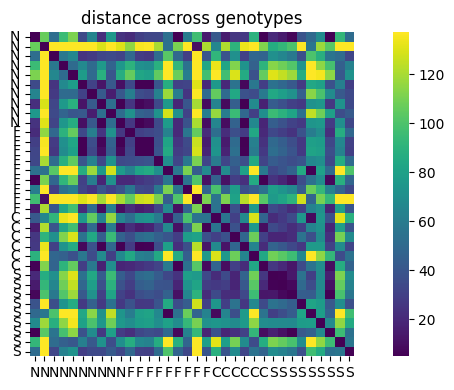

In [93]:
from matplotlib.colors import Normalize

from metric import dsd
S = len(all_subjects_reshaped)
dist_neural = dsd([
    [all_subjects_reshaped[i],all_subjects_reshaped[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural, xticklabels=all_genotypes, yticklabels=all_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

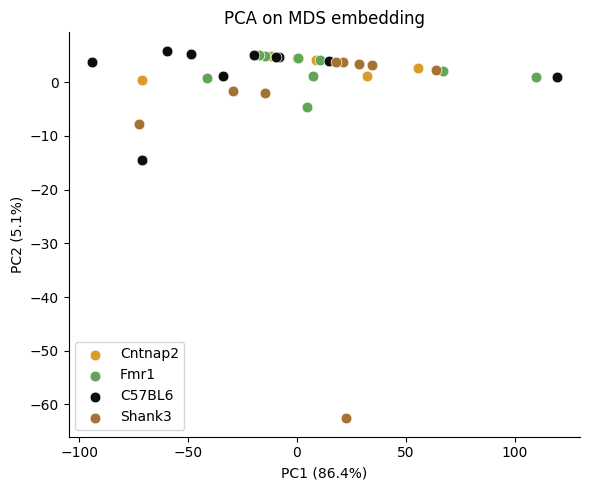

In [94]:
plot_mds_pca(dist_neural, all_genotypes)

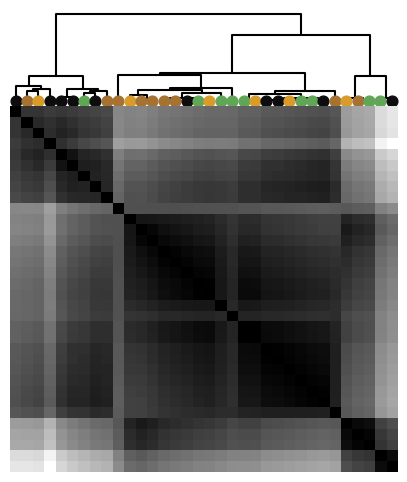

In [95]:
labels_arr = np.array(all_genotypes)
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}

plot_dendogram(dist_neural, all_genotypes, lab_to_color=colors)

### Using all neurons

In [90]:
# What can i do now? I can maybe try to cluster the kernels across genotypes
# Maybe I can, instead of using all neurons, selecting just the areas in common?

all_subjects = []
all_genotypes=[]
for g in genotypes:
    arrs = genotype_kernels_neurons[g]
    arrs = [a[:,3:6,:] for a in arrs] #[:,3:6,:]
    if len(arrs) == 0:
        continue
        
    # Just filter out the subjects with less than 100 neurons, but keep all neurons
    vals = [a.reshape(a.shape[0], -1).T for a in arrs if len(a) >= 100] # (n_neurons, contrast*timepoints) for each subject

    # Maybe do a mean across all time points?
    #vals = [a.mean(-1).T for a in arrs if (len(a) >= 100) ] # (n_neurons, contrast) for each subject
    if g=='N':
        # Remove this subject of N because it has a very different activity and messes with the clustering
        vals.pop(3)

    all_genotypes.extend([g]*len(vals))

    # Now vals has the shape (subjects, timepoints * conditions, neurons)
    all_subjects.extend(vals)


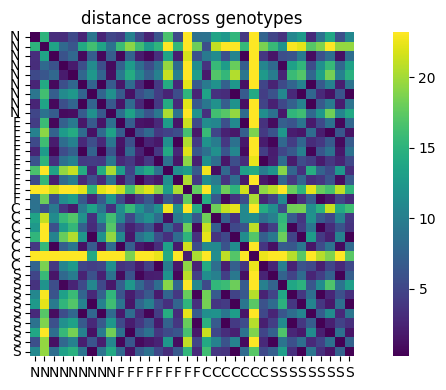

In [ ]:

S = len(all_subjects)
dist_neural = dsd([
    [all_subjects[i], all_subjects[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural, xticklabels=all_genotypes, yticklabels=all_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

<Axes: title={'center': 'PCA on MDS embedding'}, xlabel='PC1 (82.4%)', ylabel='PC2 (14.3%)'>

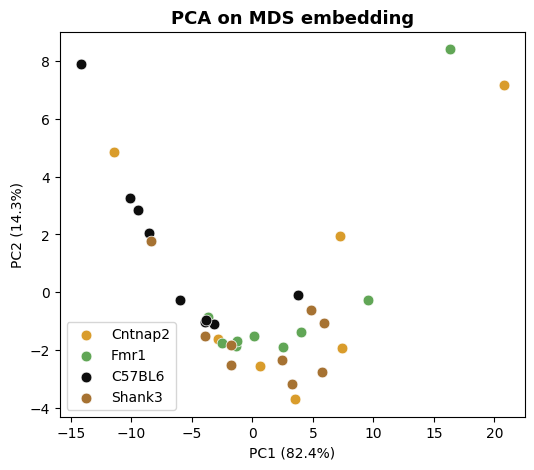

In [92]:
plot_mds_pca(dist_neural, all_genotypes)

<Axes: title={'center': 'TSNE on MDS embedding'}, xlabel='tSNE1', ylabel='tSNE2'>

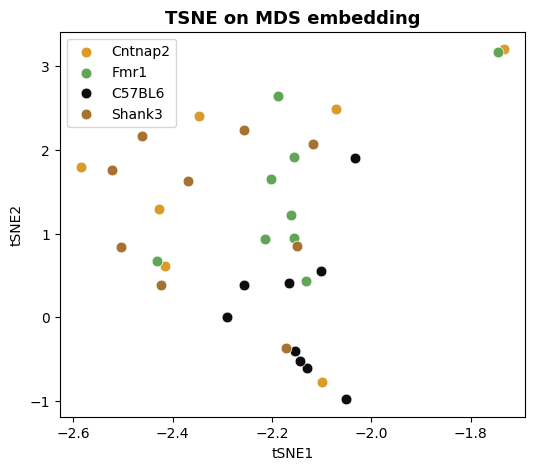

In [93]:
plot_mds_tsne(dist_neural, all_genotypes, perplexity=25)


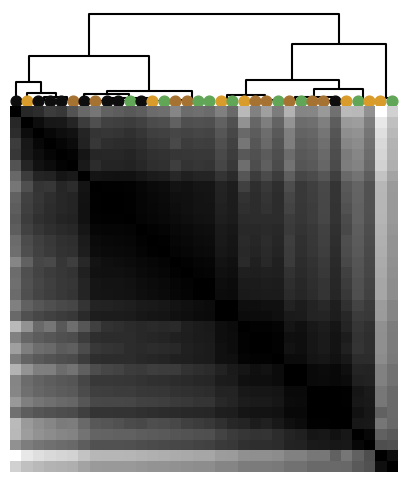

In [94]:
labels_arr = np.array(all_genotypes)
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}

plot_dendogram(dist_neural, all_genotypes, lab_to_color=colors)

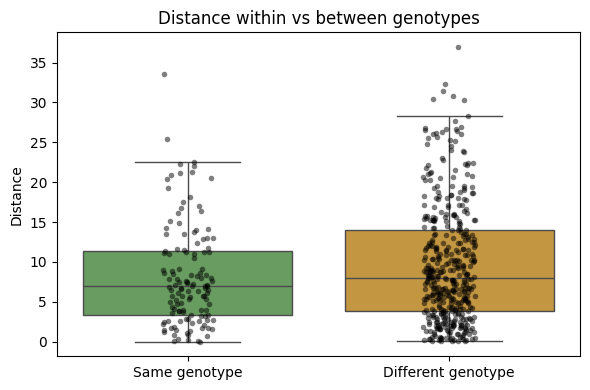

In [69]:
labels_arr = np.array(all_genotypes)
same_genotype = labels_arr[None,:] == labels_arr[None,:].T
diff_genotype = labels_arr[None, :] != labels_arr[None,:].T

S = len(labels_arr)
up_tri = np.triu_indices(S,1)

# Take just the upper part of the dist matrix
same_gen_indices = np.where(same_genotype[up_tri])
diff_gen_indices = np.where(diff_genotype[up_tri])

same_gen_distances = dist_neural[up_tri][same_gen_indices]
diff_gen_distances = dist_neural[up_tri][diff_gen_indices]
plt.figure(figsize=(6,4))
sns.boxplot(data=[same_gen_distances, diff_gen_distances], palette=['#61A656', '#D99C2B'], showfliers=False)
sns.stripplot(data=[same_gen_distances, diff_gen_distances], color='black', alpha=0.5, size=4, jitter=True)
plt.xticks([0, 1], ['Same genotype', 'Different genotype'])
plt.ylabel('Distance')
plt.title('Distance within vs between genotypes')
plt.tight_layout()
plt.show()


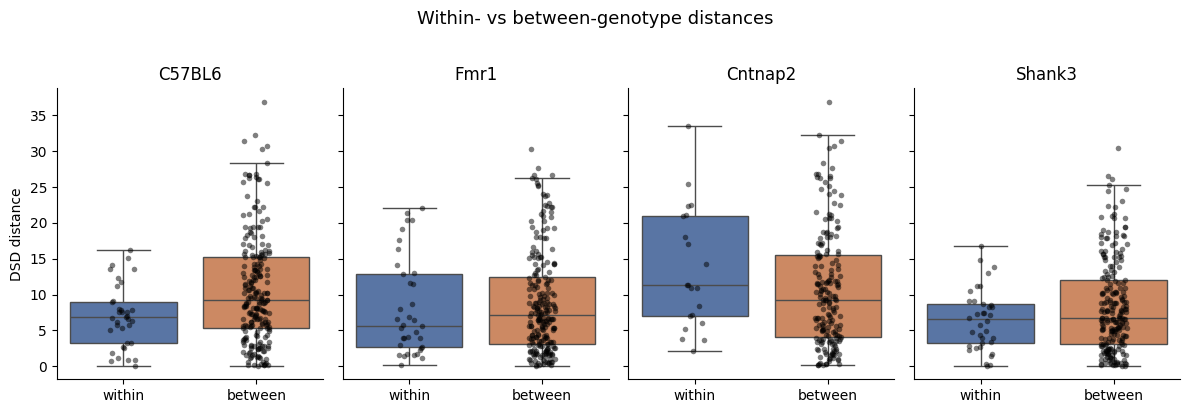

In [70]:

# For each genotype: within-genotype distances vs between-genotype distances
labels_arr = np.array(all_genotypes)
genotype_order = [g for g in ['N', 'F', 'C', 'S'] if g in labels_arr]

records = []
S_fc = dist_neural.shape[0]
for i in range(S_fc):
    for j in range(i + 1, S_fc):
        if labels_arr[i] == labels_arr[j]:
            records.append({'genotype': labels_arr[i], 'kind': 'within', 'distance': dist_neural[i, j]})
        else:
            records.append({'genotype': labels_arr[i], 'kind': 'between', 'distance': dist_neural[i, j]})
            records.append({'genotype': labels_arr[j], 'kind': 'between', 'distance': dist_neural[i, j]})

df_dist = pd.DataFrame(records)
palette = {'within': '#4C72B0', 'between': '#DD8452'}

fig, axes = plt.subplots(1, len(genotype_order), figsize=(3 * len(genotype_order), 4), sharey=True)
if len(genotype_order) == 1:
    axes = [axes]

for ax, g in zip(axes, genotype_order):
    df_g = df_dist[df_dist['genotype'] == g]
    sns.boxplot(data=df_g, x='kind', y='distance', hue='kind', order=['within', 'between'],
                   palette=palette, showfliers=False, ax=ax)
    sns.stripplot(data=df_g, x='kind', y='distance', order=['within', 'between'],
                  color='black', alpha=0.5, size=4, jitter=True, ax=ax)
    ax.set_title(map_labels.get(g, g), fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('DSD distance' if g == genotype_order[0] else '')

plt.suptitle('Within- vs between-genotype distances', fontsize=13, y=1.02)
sns.despine()
plt.tight_layout()
plt.show()


In [71]:
# How to test whether the distance between genotypes is significant? 
# I can do a permutation test where I shuffle the genotype labels and recompute the distance matrix

# Null hypothesis: the distance between genotypes is not different from the distance within genotypes

labels = np.array(all_genotypes)
n_perms=10000
p_value, perm_stats, obs_stat = permutation_test(dist_neural, labels, n_perms=n_perms)


Observed statistic (between - within): 1.3823
p-value: 0.0113


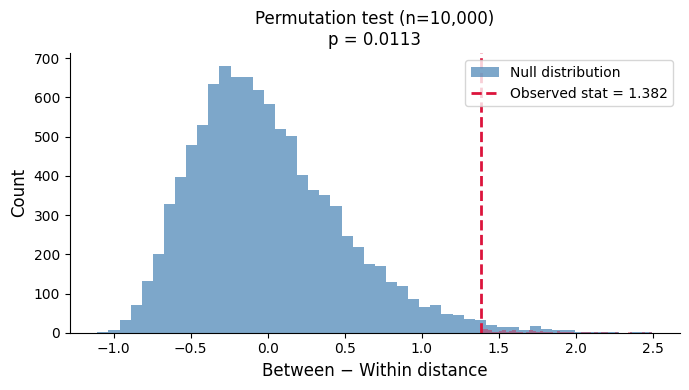

In [72]:
# Visualize the null distribution and observed statistic
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(perm_stats, bins=50, color='steelblue', alpha=0.7, label='Null distribution')
ax.axvline(obs_stat, color='crimson', linewidth=2, linestyle='--', label=f'Observed stat = {obs_stat:.3f}')

# Shade the tail (p-value region)
tail = perm_stats[perm_stats >= obs_stat]
if len(tail) > 0:
    ax.hist(tail, bins=50, color='crimson', alpha=0.4)

ax.set_xlabel('Between − Within distance', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Permutation test (n={n_perms:,})\np = {p_value:.4f}', fontsize=12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

In [59]:
# Another way could be by doing PERMANOVA (search more detailed)

from skbio.stats.distance import DistanceMatrix, permanova

dist_neural_sym = (dist_neural + dist_neural.T) / 2
dist_neural_sym[np.diag_indices_from(dist_neural_sym)] = 0
S = dist_neural_sym.shape[0]
ids = [str(i) for i in range(S)]
dm = DistanceMatrix(dist_neural_sym, ids=ids)

result = permanova(dm, labels, permutations=10000)
print(result)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      35
number of groups                  4
test statistic             1.612467
p-value                    0.182982
number of permutations        10000
Name: PERMANOVA results, dtype: object


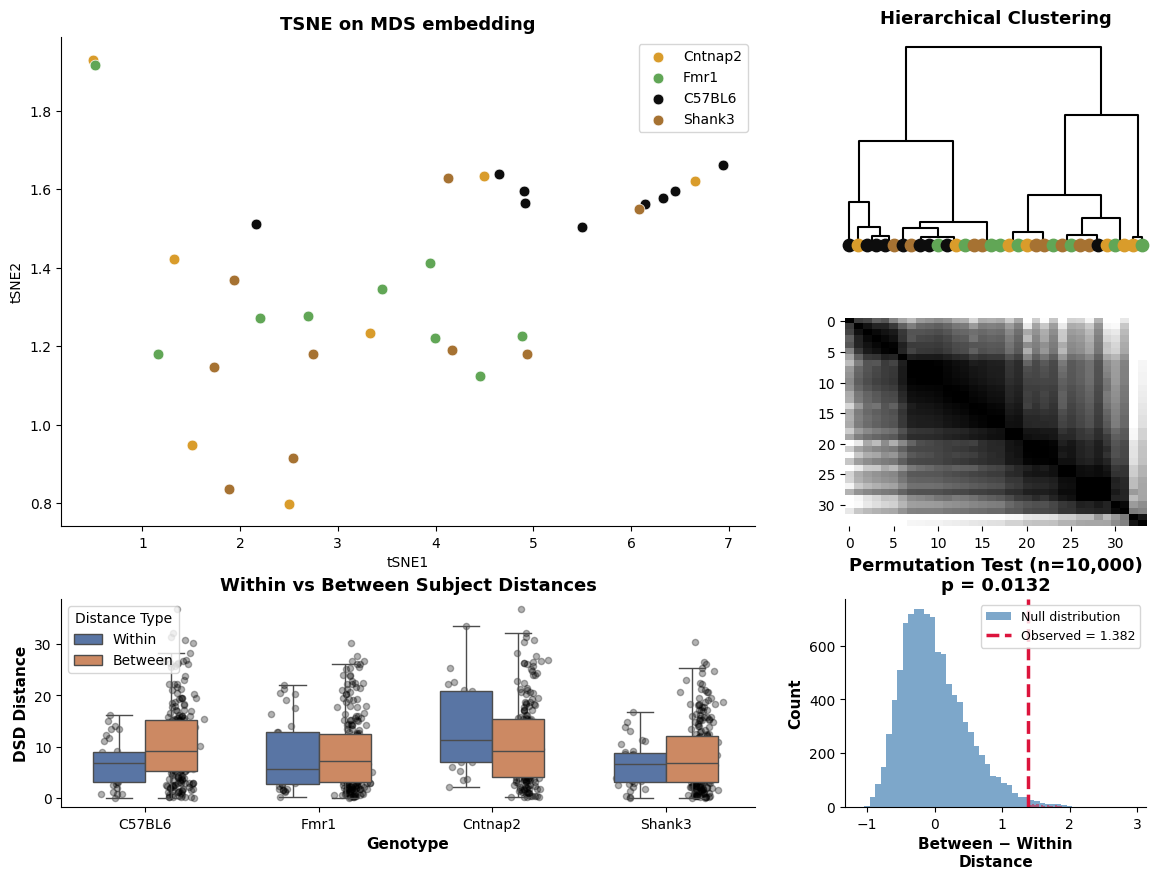

In [ ]:
def create_comprehensive_figure(dist_neural, all_genotypes, all_subjects, perm_stats=None, obs_stat=None, n_perms=None):
    """
    Create a comprehensive multi-axes figure combining:
    - PCA on MDS embedding
    - Hierarchical clustering
    - Boxplot of within vs between distances per genotype
    - Histogram of permutation test statistics
    """
    labels = np.array(all_genotypes)
    colors_map = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}
    genotype_order = [g for g in ['N', 'F', 'C', 'S'] if g in labels]
    
    # Create figure with specific layout
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # PCA on MDS embedding (large plot on the left)
    ax_pca = fig.add_subplot(gs[0:2, 0:2])
    ax_pca = plot_mds_tsne(dist_neural, labels, ax=ax_pca)
    #ax_pca.set_xticks([])
    #ax_pca.set_yticks([])
    ax_pca.legend(loc='best', fontsize=10)
    sns.despine(ax=ax_pca)
    
    # 2. Hierarchical clustering heatmap (top right)
    ax_dendro = fig.add_subplot(gs[0, 2])
    ax_heatmap = fig.add_subplot(gs[1, 2])
    
    S = dist_neural.shape[0]
    dist_neural_flat = dist_neural[np.triu_indices(S, 1)]
    linkage = hierarchy.ward(dist_neural_flat)
    linkage = hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat)
    
    dn = hierarchy.dendrogram(linkage, ax=ax_dendro, color_threshold=0, 
                               above_threshold_color='k', no_labels=True)
    ax_dendro.axis('off')
    ax_dendro.set_title('Hierarchical Clustering', fontsize=13, fontweight='bold', pad=10)
    
    leaf_order = hierarchy.leaves_list(hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat))
    x_coords = np.arange(5, S * 10 + 5, 10)
    
    for i, original_idx in enumerate(leaf_order):
        lab = labels[original_idx]
        color = colors_map[lab]
        ax_dendro.scatter(x_coords[i], 0, color=color, s=80, zorder=10, clip_on=False)
    
    ordered_dist = dist_neural[leaf_order, :][:, leaf_order]
    im = ax_heatmap.imshow(ordered_dist, cmap="gray", aspect='auto',
                           vmin=np.percentile(ordered_dist, 5), 
                           vmax=np.percentile(ordered_dist, 95))
    #ax_heatmap.set_xticks([])
    #ax_heatmap.set_yticks([])
    for spine in ax_heatmap.spines.values():
        spine.set_visible(False)
    
    # 3. Boxplot: within vs between per genotype (middle left and middle center)
    ax_box = fig.add_subplot(gs[2, 0:2])
    
    records = []
    S_fc = dist_neural.shape[0]
    for i in range(S_fc):
        for j in range(i + 1, S_fc):
            if labels[i] == labels[j]:
                records.append({'genotype': labels[i], 'kind': 'Within', 'distance': dist_neural[i, j]})
            else:
                records.append({'genotype': labels[i], 'kind': 'Between', 'distance': dist_neural[i, j]})
                records.append({'genotype': labels[j], 'kind': 'Between', 'distance': dist_neural[i, j]})
    
    df_dist = pd.DataFrame(records)
    
    # Filter and plot
    plot_order = [g for g in genotype_order if g in df_dist['genotype'].values]
    sns.boxplot(data=df_dist, x='genotype', y='distance', hue='kind', 
                order=plot_order, hue_order=['Within', 'Between'],
                palette={'Within': '#4C72B0', 'Between': '#DD8452'},
                showfliers=False, ax=ax_box, width=0.6)
    
    # Plot individual points for within/between distributions
    within_df = df_dist[df_dist['kind'] == 'Within']
    between_df = df_dist[df_dist['kind'] == 'Between']
    
    for i, g in enumerate(plot_order):
        w_data = within_df[within_df['genotype'] == g]['distance'].values
        b_data = between_df[between_df['genotype'] == g]['distance'].values
        
        x_jitter_w = np.random.normal(i - 0.2, 0.04, size=len(w_data))
        x_jitter_b = np.random.normal(i + 0.2, 0.04, size=len(b_data))
        
        ax_box.scatter(x_jitter_w, w_data, color='black', alpha=0.3, s=20, zorder=1)
        ax_box.scatter(x_jitter_b, b_data, color='black', alpha=0.3, s=20, zorder=1)
    
    ax_box.set_xlabel('Genotype', fontsize=11, fontweight='bold')
    ax_box.set_ylabel('DSD Distance', fontsize=11, fontweight='bold')
    ax_box.set_title('Within vs Between Subject Distances', fontsize=13, fontweight='bold')
    ax_box.set_xticks(range(len(plot_order)))
    ax_box.set_xticklabels([map_labels.get(g, g) for g in plot_order], fontsize=10)
    ax_box.legend(title='Distance Type', fontsize=10, title_fontsize=10, loc='upper left')
    sns.despine(ax=ax_box)
    
    # 4. Histogram of permutation test (middle right)
    ax_hist = fig.add_subplot(gs[2, 2])
    
    if perm_stats is not None and obs_stat is not None:
        ax_hist.hist(perm_stats, bins=50, color='steelblue', alpha=0.7, label='Null distribution')
        ax_hist.axvline(obs_stat, color='crimson', linewidth=2.5, linestyle='--', 
                        label=f'Observed = {obs_stat:.3f}')
        
        # Shade the tail
        tail = perm_stats[perm_stats >= obs_stat]
        if len(tail) > 0:
            ax_hist.hist(tail, bins=50, color='crimson', alpha=0.5)
        
        p_value = np.mean(perm_stats >= obs_stat)
        ax_hist.set_xlabel('Between − Within\nDistance', fontsize=11, fontweight='bold')
        ax_hist.set_ylabel('Count', fontsize=11, fontweight='bold')
        ax_hist.set_title(f'Permutation Test (n={n_perms:,})\np = {p_value:.4f}', 
                         fontsize=13, fontweight='bold')
        ax_hist.legend(fontsize=9, loc='upper right')
        sns.despine(ax=ax_hist)
    
    return fig

# Create the comprehensive figure
fig = create_comprehensive_figure(dist_neural, all_genotypes, all_subjects, 
                                   perm_stats, obs_stat, n_perms)

#fig.savefig('clustering_genotypes.svg', dpi=300, bbox_inches='tight')
plt.show()

### Separate across macroregions

In [6]:
# What if i mapped each area to its macroregion, averaged the neurons across the macroregion and used this to represent the subjects?
# Like this I could have a representation that accounts for the differences in the number of neurons and the behavior of areas
area_to_macro = {
    'CA1': 'HIP', 
    'CA3': 'HIP', 
    'DG': 'HIP', 
    'POST': 'HIP', 
    'ProS': 'HIP', 
    'SUB': 'HIP',
    'MB': 'MB', 
    'MRN': 'MB', 
    'SC': 'MB', 
    'SNr': 'MB', 
    'PRT': 'MB',
    'ACAd': 'FC', 
    'ACAv': 'FC', 
    'MOs': 'FC',
    'MOp': 'SM', 
    'RSPd': 'SM', 
    'RSPv': 'SM',
    'CP': 'STR', 
    'LS': 'STR', 
    'TRS': 'STR', 
    'SF': 'STR',
    'LD': 'TH', 
    'LGd': 'TH', 
    'LP': 'TH', 
    'MG': 'TH', 
    'PO': 'TH', 
    'PVT': 'TH', 
    'TH': 'TH', 
    'SGN': 'TH',
    'VISa': 'VIS', 
    'VISam': 'VIS', 
    'VISp': 'VIS',
    #'P': 'Other', 
    #'PRNr': 'Other'
}

### Use common regions

In [ ]:
genotype_kernels = defaultdict(list)
all_animals = []
macro_names = sorted(set(area_to_macro.values()))

for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    for animal in animals_g:
        # map each region to its macroregion
        macro_kernels = defaultdict(list)  # each element will be of size (n_units, n_contrasts, n_time_bins)
        
        for region in regions:
            macro = area_to_macro.get(region)
            if macro is None:
                continue

            region_kernel = load_animal_region_kernels(g, animal, region)

            if len(region_kernel) == 0:
                continue

            # Filter outliers
            region_kernel = filter_kernels_outliers(region_kernel, 95, 5)
            macro_kernels[macro].append(region_kernel)

        # Average neurons within each macroregion -> (n_macroregions, n_contrasts, n_time_bins)
        macro_avg = []
        for macro in macro_names:
            # For each macroregion of this subject
            if macro in macro_kernels:
                combined = np.concatenate(macro_kernels[macro], axis=0)  # (n_units, n_contrasts, n_time_bins)
                macro_avg.append(combined.mean(axis=0))  # (n_contrasts, n_time_bins)

        # Skip if not all regions are included
        # Doesnt work... it will remove all subjects of some gentypes....
        """if len(macro_avg) < len(macro_names):
            print(f"Warning: Subject {animal} of genotype {g} is missing some macroregions. Found: {list(macro_kernels.keys())}")
            continue"""

        animal_macro_kernel = np.stack(macro_avg, axis=0)  # (n_macroregions, n_contrasts, n_time_bins)
        genotype_kernels[g].append(animal_macro_kernel)

        all_animals.extend(animals_g)

# Detect and remove outlier subjects based on mean kernel amplitude
for g in genotypes:
    arrs = genotype_kernels[g]
    if len(arrs) < 3:
        continue
    keep_mask, amps = detect_outlier_subjects(arrs, mad_factor=3.0)
    n_removed = (~keep_mask).sum()
    if n_removed > 0:
        removed_idx = np.where(~keep_mask)[0]
        print(f"Genotype {g}: removing {n_removed} outlier subject(s) "
              f"(indices {removed_idx.tolist()}, amplitudes: {amps[removed_idx].round(3)})")
        genotype_kernels[g] = [a for a, m in zip(arrs, keep_mask) if m]
    else:
        print(f"Genotype {g}: no outliers (amplitudes: {amps.round(3)})")

print(f"\nMacroregions: {macro_names}")
print(f"Shape per animal: {genotype_kernels[genotypes[0]][0].shape}")  # (n_macroregions, n_contrasts, n_time_bins)


/tmp/ipykernel_3911400/1785194642.py:33: RuntimeWarning: Mean of empty slice.
  macro_avg.append(combined.mean(axis=0))  # (n_contrasts, n_time_bins)


Macroregions: ['FC', 'HIP', 'MB', 'SM', 'STR', 'TH', 'VIS']
Shape per animal: (7, 9, 106)


In [ ]:
# What can i do now? I can maybe try to cluster the kernels across genotypes
# Maybe I can, instead of using all neurons, selecting just the areas in common?

all_subjects_regions = []
all_genotypes=[]
for g in genotypes:
    arrs = genotype_kernels[g]
    if len(arrs) == 0:
        continue
        
    # Get the 100 least variable neurons across all animals for this genotype and contrast
    vals = np.stack(arrs) # (subjects, regions, contrasts, timepoints)

    all_genotypes.extend([g]*len(vals))

    # Now vals has the shape (subjects, timepoints * conditions, neurons)
    all_subjects_regions.append(vals)

all_subjects_regions = np.concatenate(all_subjects_regions, axis=0) # (subjects, regions, contrasts, timepoints)
S, r, c, t = all_subjects_regions.shape
all_subjects_regions = all_subjects_regions.reshape(S, r, c*t).transpose(0,2,1) # (subjects, contrast*timepoints, regions)
#all_subjects_reshaped = all_subjects.mean(-1).transpose(0,2,1) # (subjects, contrast, regions)


In [94]:
all_subjects_regions.shape

(13, 954, 7)

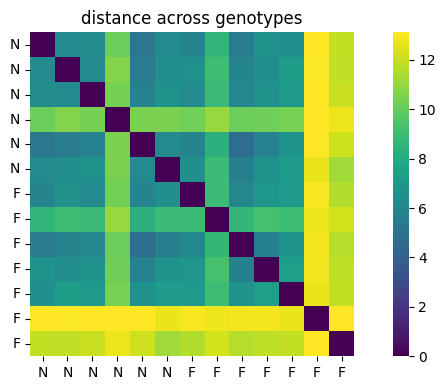

In [95]:
from matplotlib.colors import Normalize

from metric import dsd

dist_neural = dsd([
    [all_subjects_regions[i],all_subjects_regions[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural, xticklabels=all_genotypes, yticklabels=all_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

### Combining macroregions 

In [31]:
all_animals = []
macro_names = sorted(set(area_to_macro.values()))
subject_macro_kernels = []  # list of dicts {macro: array(n_units, n_contrasts, n_time_bins)}
fc_genotypes = []

for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    for animal in animals_g:
        macro_kernels = defaultdict(list)
        for region in regions:
            macro = area_to_macro.get(region)
            if macro is None:
                continue

            region_kernel = load_animal_region_kernels(g, animal, region)  # (units, n_contrasts, time_bins)

            if len(region_kernel) == 0:
                continue

            macro_kernels[macro].append(region_kernel[:,3:6,:])

        # Concatenate neurons within each macroregion
        animal_macro = {
            macro: np.concatenate(kernels, axis=0)  # (n_units, n_contrasts, n_time_bins)
            for macro, kernels in macro_kernels.items()
        }

        if len(animal_macro) > 0:
            subject_macro_kernels.append(animal_macro)
            fc_genotypes.append(g)

# Filter out subjects with too few total neurons across all macroregions
filtered_macro_kernels = []
filtered_genotypes = []
for animal_macro, g in zip(subject_macro_kernels, fc_genotypes):
    animal_filter = {macro: kernel for macro, kernel in animal_macro.items() if kernel.shape[0] >= 50}
    filtered_macro_kernels.append(animal_filter)
    filtered_genotypes.append(g)
    
    """total_neurons = sum(v.shape[0] for v in animal_macro.values())
    if total_neurons >= 50:
        filtered_macro_kernels.append(animal_macro) # It is a list of dictionaries for each subject
        filtered_genotypes.append(g)"""

print(f"Subjects kept: {len(filtered_macro_kernels)}")
print(f"Macroregions found: {sorted(set(m for s in filtered_macro_kernels for m in s.keys()))}")


Subjects kept: 39
Macroregions found: ['FC', 'HIP', 'MB', 'SM', 'STR', 'TH', 'VIS']


Distance matrix shape: (39, 39), macroregions summed: ['FC', 'HIP', 'MB', 'SM', 'STR', 'TH', 'VIS']


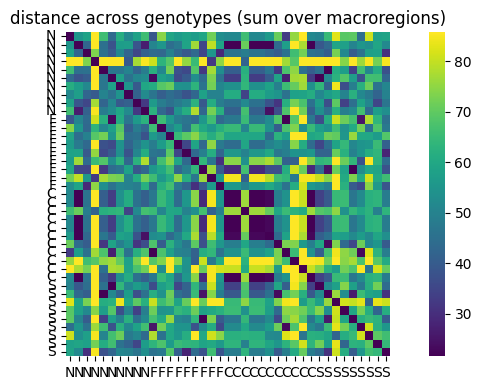

In [ ]:
from matplotlib.colors import Normalize
from metric import dsd

S = len(filtered_macro_kernels)
all_macros = sorted(set(m for s in filtered_macro_kernels for m in s.keys()))

# For each macroregion, compute pairwise distances and accumulate into the total
dist_neural = np.zeros((S, S))
# iterate over all macroregions
for macro in all_macros:
    # Reshape (contrast*time, n_units) and none if no macroregion
    macro_data = [
        s[macro].reshape(s[macro].shape[0], -1).T if macro in s else np.zeros((318,100))  # (contrast*time, n_units) or empty if missing
        for s in filtered_macro_kernels
    ]

    # Pairs where both subjects have this macroregion
    pairs = [(i, j) for i in range(S) for j in range(S)
             if macro_data[i] is not None and macro_data[j] is not None]
    
    if not pairs:
        continue

    pair_dists = dsd([[macro_data[i], macro_data[j]] for i, j in pairs])
    for (i, j), d in zip(pairs, pair_dists):
        dist_neural[i, j] += d

print(f"Distance matrix shape: {dist_neural.shape}, macroregions summed: {all_macros}")

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)
vmax = np.quantile(dist_neural.flatten(), 0.95)

sns.heatmap(dist_neural, xticklabels=filtered_genotypes, yticklabels=filtered_genotypes, cmap='viridis',
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes (sum over macroregions)', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


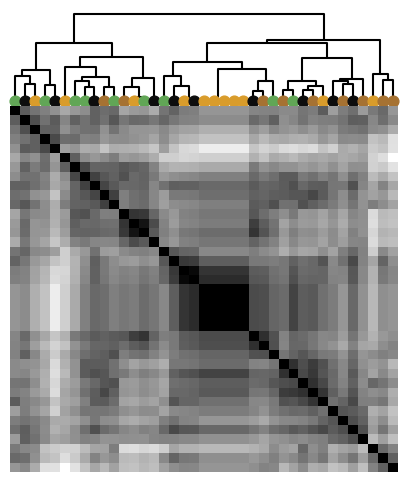

In [58]:
labels_arr = np.array(filtered_genotypes)
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}

plot_dendogram(dist_neural, labels_arr, lab_to_color=colors)

In [59]:
print(dist_neural[:9,:].mean(0)[9].mean())
print(dist_neural[:9,:].mean(0)[9:].mean())

51.57780710656307
55.20928357979638


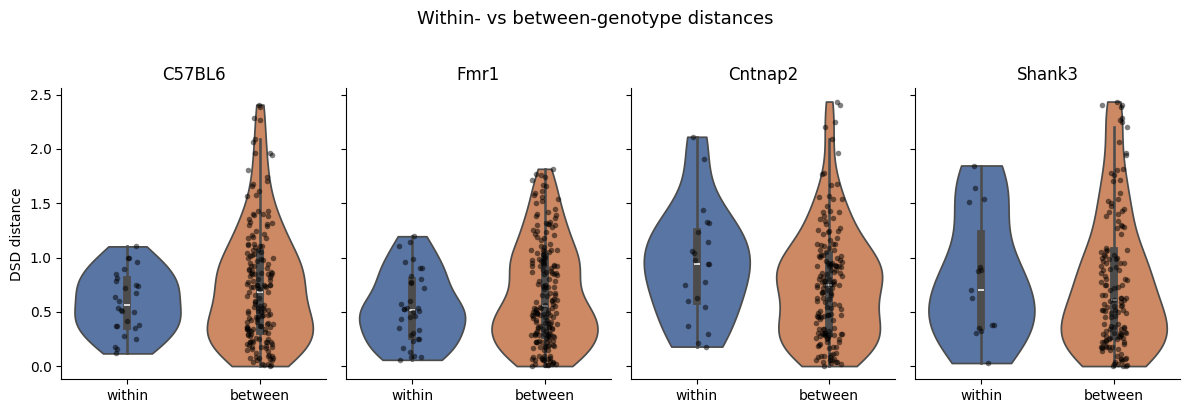

In [264]:

# For each genotype: within-genotype distances vs between-genotype distances
labels_arr = np.array(fc_genotypes)
genotype_order = [g for g in ['N', 'F', 'C', 'S'] if g in labels_arr]

records = []
S_fc = dist_neural.shape[0]
for i in range(S_fc):
    for j in range(i + 1, S_fc):
        if labels_arr[i] == labels_arr[j]:
            records.append({'genotype': labels_arr[i], 'kind': 'within', 'distance': dist_neural[i, j]})
        else:
            records.append({'genotype': labels_arr[i], 'kind': 'between', 'distance': dist_neural[i, j]})
            records.append({'genotype': labels_arr[j], 'kind': 'between', 'distance': dist_neural[i, j]})

df_dist = pd.DataFrame(records)
palette = {'within': '#4C72B0', 'between': '#DD8452'}

fig, axes = plt.subplots(1, len(genotype_order), figsize=(3 * len(genotype_order), 4), sharey=True)
if len(genotype_order) == 1:
    axes = [axes]

for ax, g in zip(axes, genotype_order):
    df_g = df_dist[df_dist['genotype'] == g]
    sns.violinplot(data=df_g, x='kind', y='distance', hue='kind', order=['within', 'between'],
                   palette=palette, inner='box', legend=False, ax=ax, cut=0)
    sns.stripplot(data=df_g, x='kind', y='distance', order=['within', 'between'],
                  color='black', alpha=0.5, size=4, jitter=True, ax=ax)
    ax.set_title(map_labels.get(g, g), fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('DSD distance' if g == genotype_order[0] else '')

plt.suptitle('Within- vs between-genotype distances', fontsize=13, y=1.02)
sns.despine()
plt.tight_layout()
plt.show()


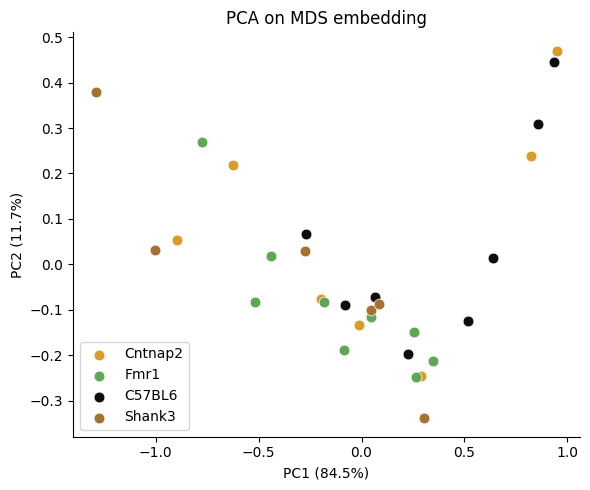

In [265]:
plot_mds_pca(dist_neural, fc_genotypes)

In [170]:
# How to test whether the distance between genotypes is significant? 
# I can do a permutation test where I shuffle the genotype labels and recompute the distance matrix

# Null hypothesis: the distance between genotypes is not different from the distance within genotypes

labels = np.array(fc_genotypes)
n_perms=10000
p_value, perm_stats, obs_stat = permutation_test(dist_neural, labels, n_perms=n_perms)


Observed statistic (between - within): 1.8357
p-value: 0.2510


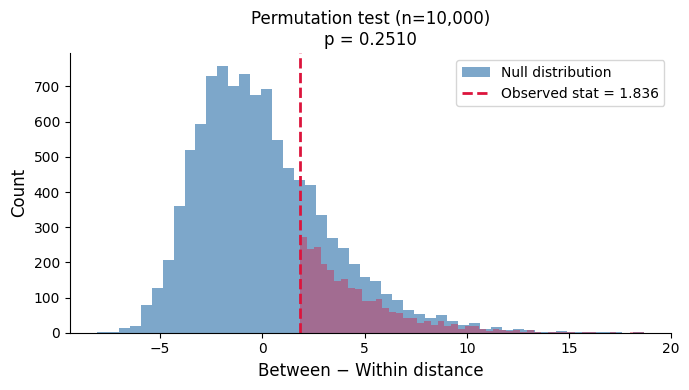

In [171]:
# Visualize the null distribution and observed statistic
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(perm_stats, bins=50, color='steelblue', alpha=0.7, label='Null distribution')
ax.axvline(obs_stat, color='crimson', linewidth=2, linestyle='--', label=f'Observed stat = {obs_stat:.3f}')

# Shade the tail (p-value region)
tail = perm_stats[perm_stats >= obs_stat]
if len(tail) > 0:
    ax.hist(tail, bins=50, color='crimson', alpha=0.4)

ax.set_xlabel('Between − Within distance', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Permutation test (n={n_perms:,})\np = {p_value:.4f}', fontsize=12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

In [92]:
# Another way could be by doing PERMANOVA (search more detailed)

from skbio.stats.distance import DistanceMatrix, permanova

dist_neural_sym = (dist_neural + dist_neural.T) / 2
dist_neural_sym[np.diag_indices_from(dist_neural_sym)] = 0
S = dist_neural_sym.shape[0]
ids = [str(i) for i in range(S)]
dm = DistanceMatrix(dist_neural_sym, ids=ids)

result = permanova(dm, fc_genotypes, permutations=10000)
print(result)

KeyboardInterrupt: 

### Get just some macroregion's neurons

In [ ]:

all_animals = []
macro_names = sorted(set(area_to_macro.values()))
fc_kernels = []  # each element will be of size (n_units, n_contrasts, n_time_bins)
fc_genotypes = []

for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    animal_fc = []
    for animal in animals_g:
        # map each region to its macroregion
        for region in regions:
            macro = area_to_macro.get(region)
            # Just take neurons from frontal regions
            if macro=='SM': # or macro=='FC' 'VIS

                region_kernel = load_animal_region_kernels(g, animal, region) # (units, contrasts, time_bins)

                if len(region_kernel) < 40: # Exclude if too few neurons (kinda arbitrary)
                    continue
            
                animal_fc.append(region_kernel) 
                # Filter outliers
        if len(animal_fc) > 0:
            # Each subject is an array of shape (n_units, n_contrasts, n_time_bins) 
            fc_kernels.append(np.concatenate(animal_fc, axis=0)) # (subjects, n_units, contrasts, timepoints)
            fc_genotypes.append(g)

In [ ]:

for i, (kernels, g) in enumerate(zip(fc_kernels, fc_genotypes)):
    print(f"Subject {i} (genotype {g}): shape {kernels.shape}")

In [ ]:
all_subjects_regions = [kernels_animal.mean(-1).T for kernels_animal in fc_kernels] # (subjects, contrast, regions)


In [ ]:


all_subjects_regions = [kernels_animal.reshape(kernels_animal.shape[0], -1).T for kernels_animal in fc_kernels] # (subjects, contrast, regions)
S = len(all_subjects_regions)
dist_neural = dsd([
    [all_subjects_regions[i],all_subjects_regions[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural, xticklabels=fc_genotypes, yticklabels=fc_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
plot_mds_pca(dist_neural, fc_genotypes)

In [ ]:
# How to test whether the distance between genotypes is significant? 
# I can do a permutation test where I shuffle the genotype labels and recompute the distance matrix

# Null hypothesis: the distance between genotypes is not different from the distance within genotypes

labels = np.array(fc_genotypes)
n_perms=10000
p_value, perm_stats, obs_stat = permutation_test(dist_neural, labels, n_perms=10000)

In [ ]:
# Visualize the null distribution and observed statistic
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(perm_stats, bins=50, color='steelblue', alpha=0.7, label='Null distribution')
ax.axvline(obs_stat, color='crimson', linewidth=2, linestyle='--', label=f'Observed stat = {obs_stat:.3f}')

# Shade the tail (p-value region)
tail = perm_stats[perm_stats >= obs_stat]
if len(tail) > 0:
    ax.hist(tail, bins=50, color='crimson', alpha=0.4)

ax.set_xlabel('Between − Within distance', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Permutation test (n={n_perms:,})\np = {p_value:.4f}', fontsize=12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()